In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder ,StandardScaler

our project is we are trying to predict the addiction score to social media  of Genz based on several features

it`s a Regresion proplem

our data :Student Social Media Addiction Analysis Dataset

source : kaggel

shape: (705,12)

target : Addicted_score

### validating the data and exploring it

In [3]:
df=pd.read_csv("dataset.csv")

In [4]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [5]:
df.duplicated().value_counts()

False    705
Name: count, dtype: int64

In [6]:
df=df.drop("Student_ID",axis=1)

In [7]:
df.duplicated().value_counts()

False    704
True       1
Name: count, dtype: int64

In [8]:
df[df.duplicated(keep=False)] 

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
241,21,Male,Graduate,Italy,5.4,Instagram,Yes,6.7,5,Single,3,7
273,21,Male,Graduate,Italy,5.4,Instagram,Yes,6.7,5,Single,3,7


In [9]:
df=df.drop_duplicates(keep="first").reset_index(drop=True)

In [10]:
df["Age"].unique()

array([19, 22, 20, 18, 21, 23, 24])

In [11]:
df.shape

(704, 12)

In [12]:
df.isnull().sum()

Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           704 non-null    int64  
 1   Gender                        704 non-null    object 
 2   Academic_Level                704 non-null    object 
 3   Country                       704 non-null    object 
 4   Avg_Daily_Usage_Hours         704 non-null    float64
 5   Most_Used_Platform            704 non-null    object 
 6   Affects_Academic_Performance  704 non-null    object 
 7   Sleep_Hours_Per_Night         704 non-null    float64
 8   Mental_Health_Score           704 non-null    int64  
 9   Relationship_Status           704 non-null    object 
 10  Conflicts_Over_Social_Media   704 non-null    int64  
 11  Addicted_Score                704 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 66.1+ KB


In [14]:
df.dtypes

Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,704.0,20.659091,1.400153,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,704.0,4.918040,1.258157,1.5,4.1,4.8,5.8,8.5
Sleep_Hours_Per_Night,704.0,6.869176,1.127631,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,704.0,6.228693,1.104871,4.0,5.0,6.0,7.0,9.0
Conflicts_Over_Social_Media,704.0,2.849432,0.958632,0.0,2.0,3.0,4.0,5.0
Addicted_Score,704.0,6.436080,1.588151,2.0,5.0,7.0,8.0,9.0


In [16]:
df.describe(include='object').T

,count,unique,top,freq
Gender,704,2,Female,353
Academic_Level,704,3,Undergraduate,353
Country,704,110,India,53
Most_Used_Platform,704,12,Instagram,248
Affects_Academic_Performance,704,2,Yes,452
Relationship_Status,704,3,Single,383


In [17]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print('#',col, ":", len(outliers), "outliers\n")

    if len(outliers) > 0:
        display(outliers)
        # but the outlers will not highly affect

# Age : 0 outliers

# Avg_Daily_Usage_Hours : 3 outliers



,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
6,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
485,20,Female,Undergraduate,USA,8.4,TikTok,Yes,3.9,5,In Relationship,4,9
495,19,Female,Undergraduate,USA,8.5,Instagram,Yes,3.8,5,In Relationship,4,9


# Sleep_Hours_Per_Night : 0 outliers

# Mental_Health_Score : 0 outliers

# Conflicts_Over_Social_Media : 0 outliers

# Addicted_Score : 0 outliers



In [18]:
pd.set_option('display.max_rows',None)
df["Country"].value_counts()


Country
India              53
USA                40
Canada             34
France             27
Mexico             27
Spain              27
Turkey             27
Ireland            27
Denmark            27
Switzerland        27
UK                 22
Japan              21
Russia             21
Italy              20
Bangladesh         20
Maldives           19
Sri Lanka          19
Nepal              19
Pakistan           19
China              16
Poland             16
Germany            14
Australia          14
South Korea        13
UAE                 8
Singapore           8
New Zealand         8
Brazil              8
Malaysia            8
Netherlands         8
Finland             8
Austria             1
Thailand            1
Philippines         1
Taiwan              1
Indonesia           1
Hong Kong           1
Israel              1
Egypt               1
Morocco             1
Vietnam             1
Belgium             1
Greece              1
Portugal            1
Sweden              1
No

In [19]:
pd.reset_option('display.max_rows')

In [20]:
df

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
699,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
700,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
701,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
702,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


#### Key Insights from Descriptive Statistics

-The dataset contains 704 students.

-The average daily social media usage is approximately 4.92 hours with a median of 4.8 hours. The average sleep duration is about 6.87 hours per night, while the average mental health score is 6.23.

-The average number of conflicts over social media is 2.85, and the average addiction score is 6.44.

-Overall, the descriptive statistics provide an overview of students social media usage, sleep, mental health, conflicts, and addiction levels.


### EDA

In [21]:
df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

1) exploring the catagorical data

In [22]:
categorical_cols=df.select_dtypes("object").columns
categorical_cols

Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Relationship_Status'],
      dtype='object')

In [23]:
sns.set_theme(style="whitegrid")

C:\Users\malak\AppData\Local\Temp\ipykernel_37488\1904446695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts().index)
C:\Users\malak\AppData\Local\Temp\ipykernel_37488\1904446695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts().index)
C:\Users\malak\AppData\Local\Temp\ipykernel_37488\1904446695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts()

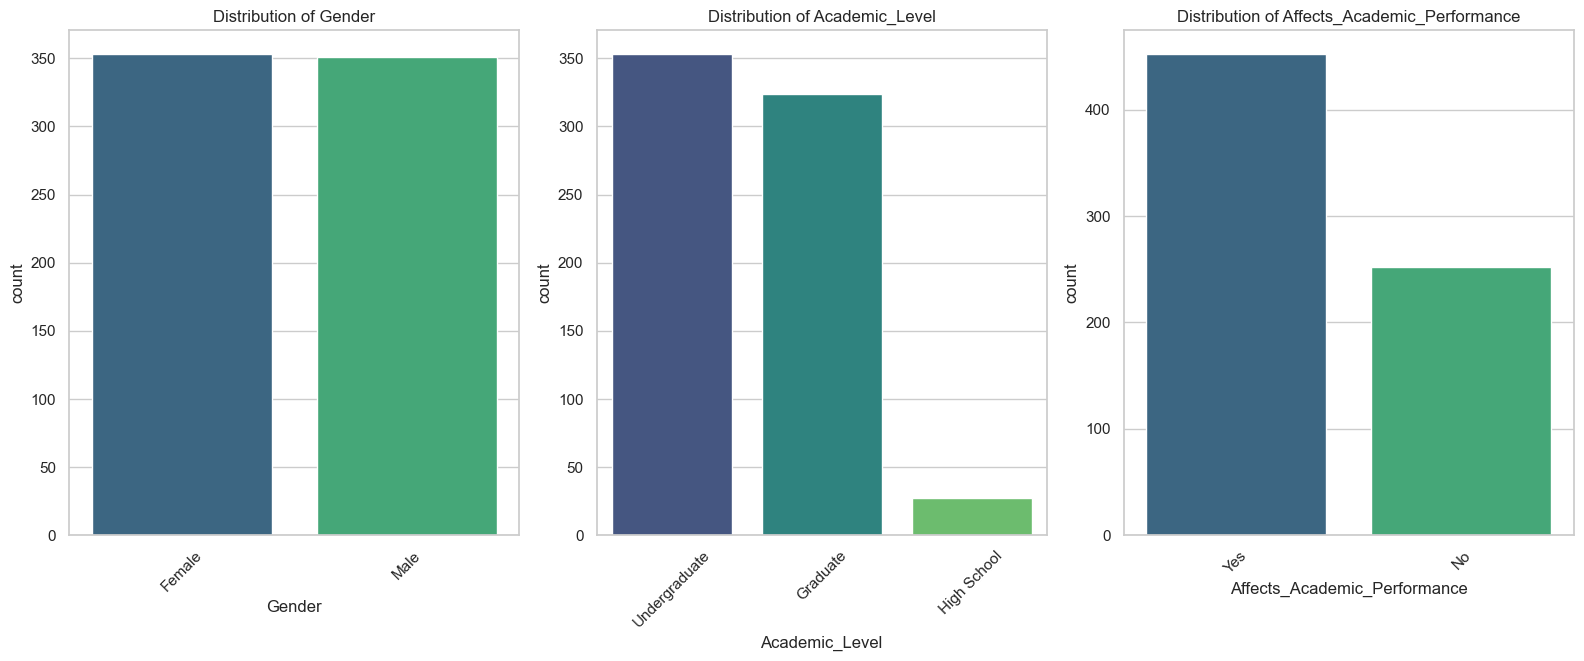

In [24]:
categorical_cols = ['Gender', 'Academic_Level','Affects_Academic_Performance', ]
plt.figure(figsize=(16, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The bar charts show that the sample is fairly balanced across gender and academic level, with no single group dominating the dataset. Most students report that social media negatively affects their academic performance, which suggests that this issue is common in the population studied. This balance strengthens the reliability of further comparisons across categories.

C:\Users\malak\AppData\Local\Temp\ipykernel_37488\4099620310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts().index)
C:\Users\malak\AppData\Local\Temp\ipykernel_37488\4099620310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts().index)
C:\Users\malak\AppData\Local\Temp\ipykernel_37488\4099620310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts()

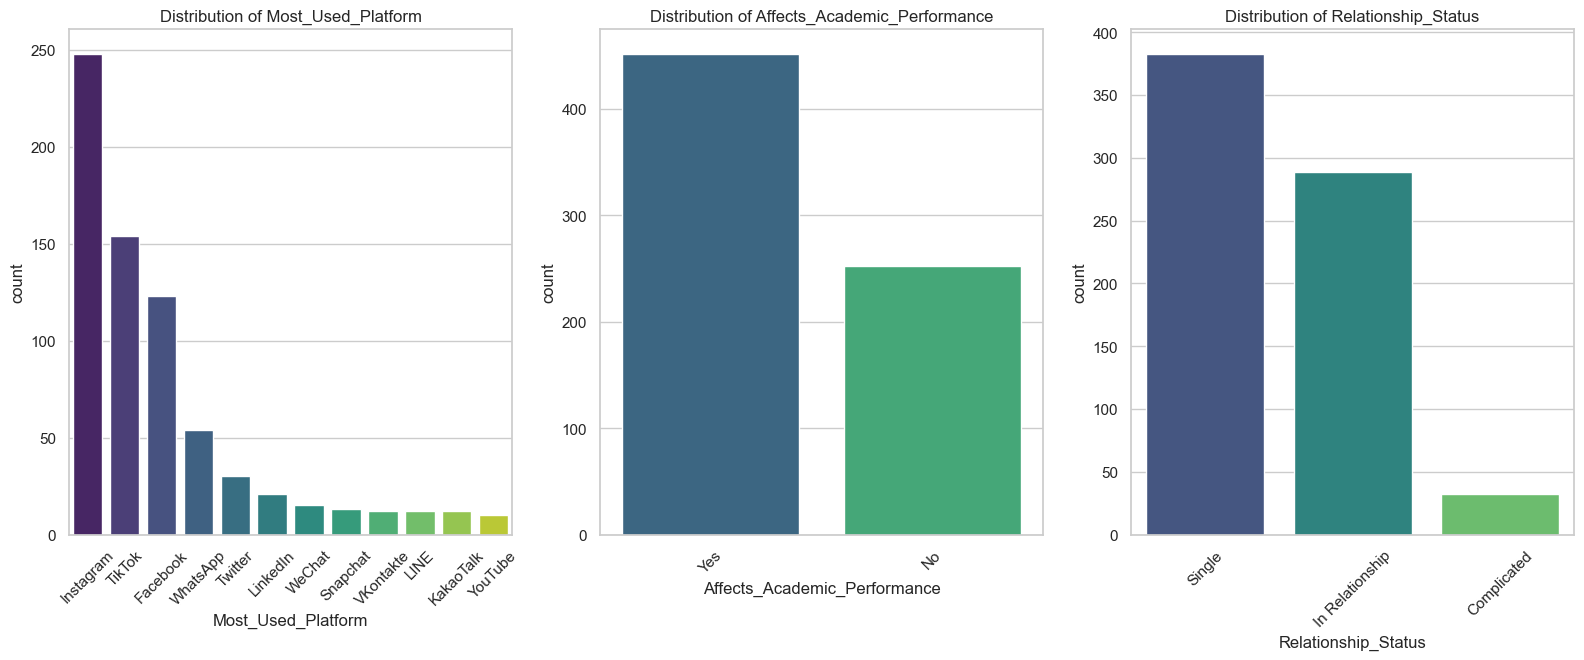

In [25]:
categorical_cols = ['Most_Used_Platform', 'Affects_Academic_Performance','Relationship_Status']
plt.figure(figsize=(16, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, palette='viridis',order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The distribution of platform use and relationship status indicates that a few platforms are more dominant than others, while relationship status is spread across several categories. This suggests that platform preference varies among students,instagram tiktok and facebook are the top3 used  . Relationship status variable may not be strongly associated with a single platform. The chart helps identify whether the dataset has a clear pattern in social media behavior by platform or relationship status.

C:\Users\malak\AppData\Local\Temp\ipykernel_37488\2847551353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Country",palette='viridis',order=df['Country'].value_counts().index)


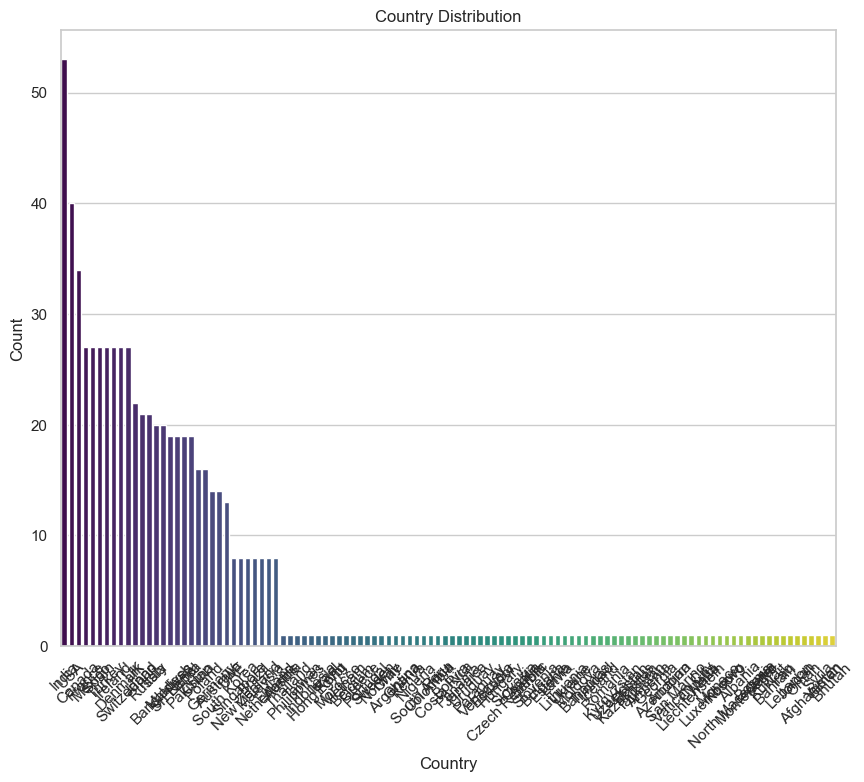

In [26]:
plt.figure(figsize=(10, 8))

sns.countplot(data=df, x="Country",palette='viridis',order=df['Country'].value_counts().index)

plt.ylabel("Count")
plt.xlabel("Country")
plt.title("Country Distribution")
plt.xticks(rotation=45)
plt.show()

2) exploring the numerical data

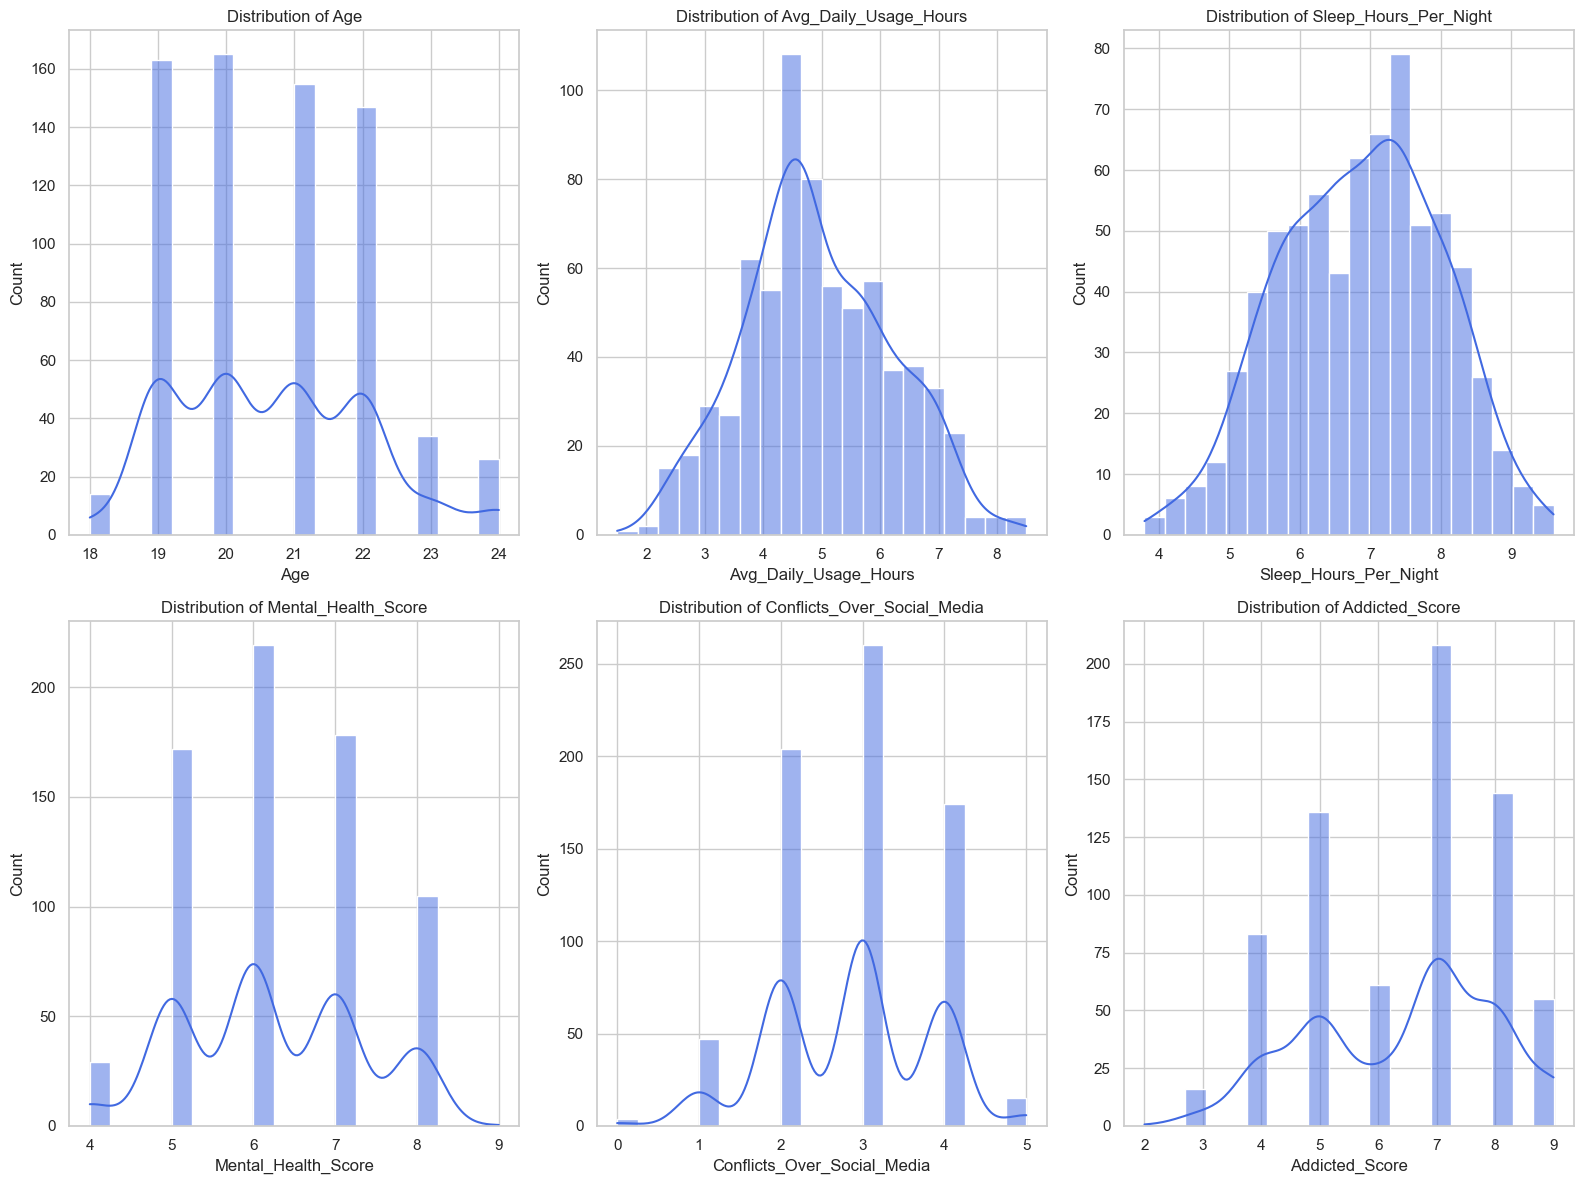

In [27]:
numerical_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                  'Mental_Health_Score', 'Conflicts_Over_Social_Media',
                  'Addicted_Score']

plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='royalblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

The histograms show that most numerical features are centered around reasonable ranges, but some variables show skewness. For example, addiction-related scores and usage hours may have a concentration of students in the middle-to-high range, while sleep hours and mental health scores may spread more widely. These shapes suggest that the data is not perfectly normal, so future modeling should consider scaling or transformations if necessary.

#### cheking outliers

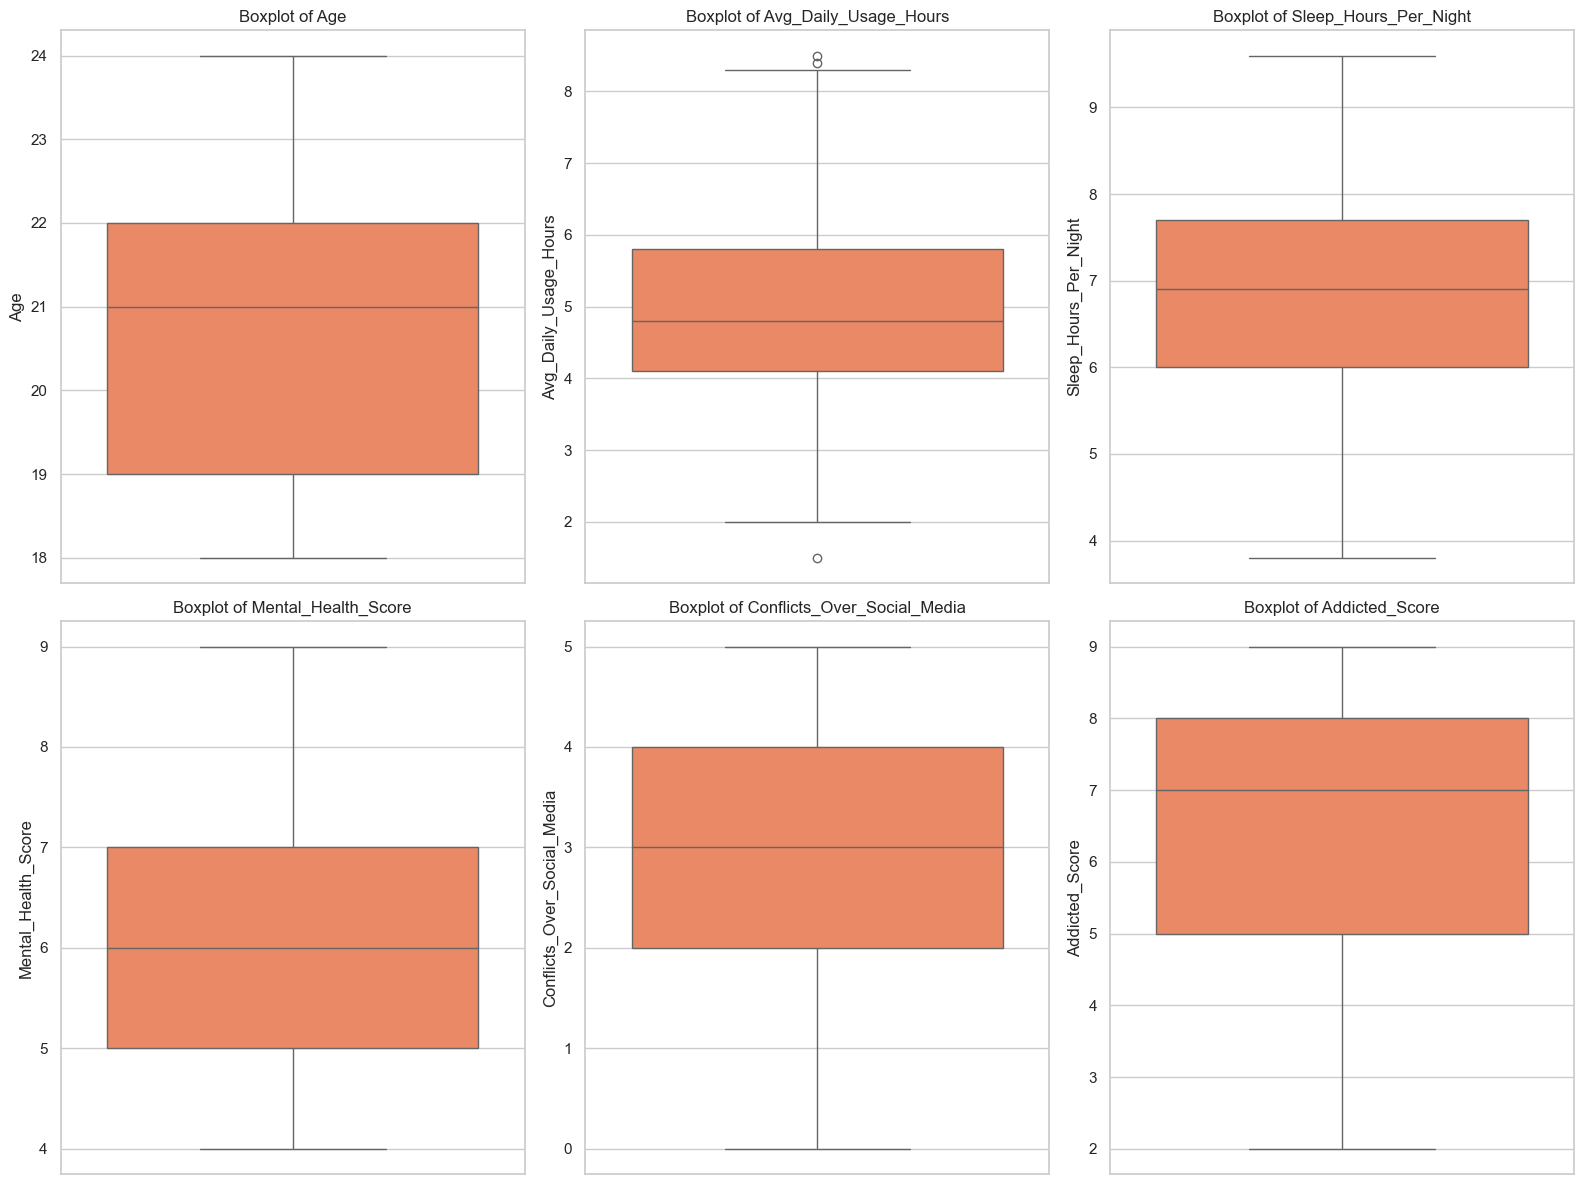

In [28]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=col, color='coral')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

this prove the previous check in the cleaning the outlires are 3 values in avarage daily usage

## cheking the relation with the target

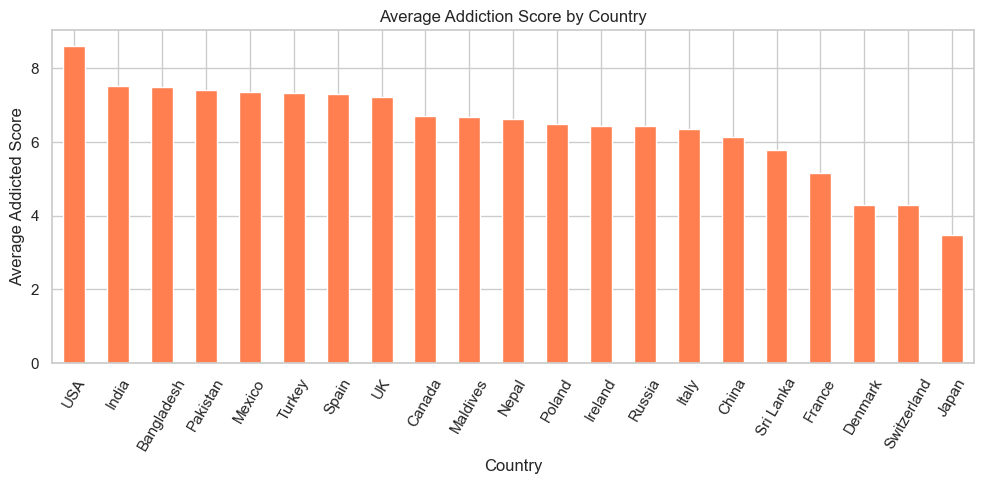

In [29]:
country_counts = df["Country"].value_counts()
valid_countries = country_counts[country_counts >= 15].index

country_addiction = (df[df["Country"].isin(valid_countries)].groupby("Country")["Addicted_Score"].mean().sort_values(ascending=False))

plt.figure(figsize=(10,5))
country_addiction.plot(kind="bar", color="coral")
plt.title("Average Addiction Score by Country")
plt.ylabel("Average Addicted Score")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

the country feature doesnt affect the target the adiction score

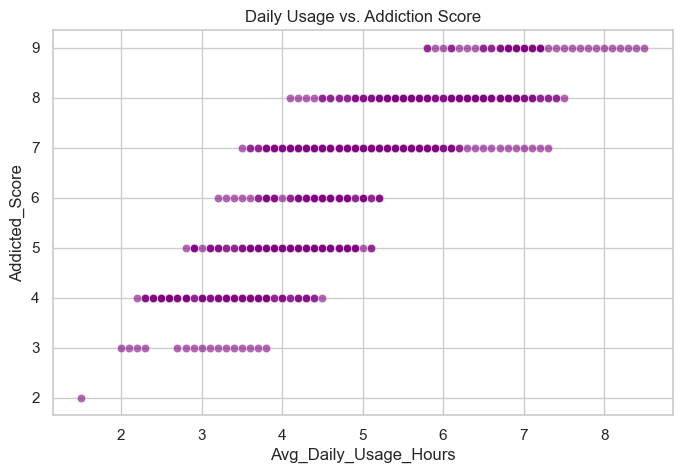

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Addicted_Score', alpha=0.6, color='purple')
plt.title('Daily Usage vs. Addiction Score')
plt.show()


plot shows the relationship between average daily usage and addiction score. The upward trend suggests that students who spend more hours on social media tend to have higher addiction scores, which is consistent with the idea that heavier usage is associated with stronger dependency patterns. The spread of points also shows that the relationship is not perfectly linear, meaning other factors may also influence addiction.

C:\Users\malak\AppData\Local\Temp\ipykernel_37488\1788085999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Most_Used_Platform', y='Addicted_Score', palette='Set2')


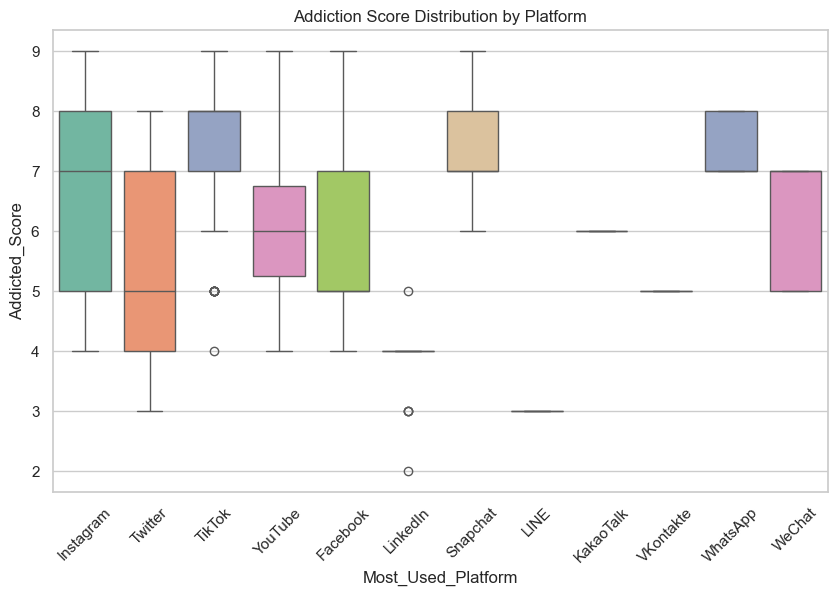

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Most_Used_Platform', y='Addicted_Score', palette='Set2')
plt.title('Addiction Score Distribution by Platform')
plt.xticks(rotation=45)
plt.show()


C:\Users\malak\AppData\Local\Temp\ipykernel_37488\3384156027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


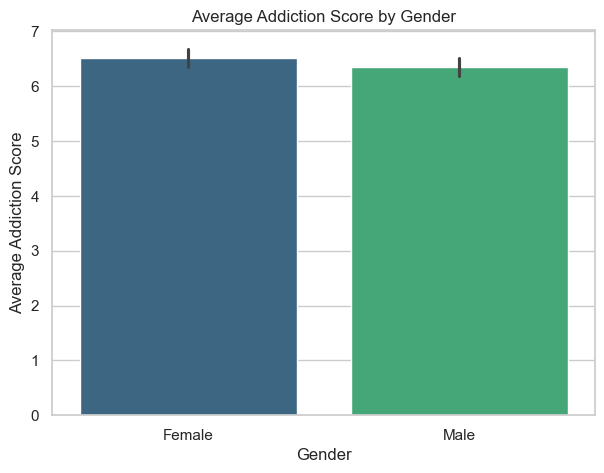

In [32]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Gender",
    y="Addicted_Score",
    palette="viridis"
)

plt.title("Average Addiction Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Addiction Score")

plt.show()

overall it doesnt realy affect the target

C:\Users\malak\AppData\Local\Temp\ipykernel_37488\3443065204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


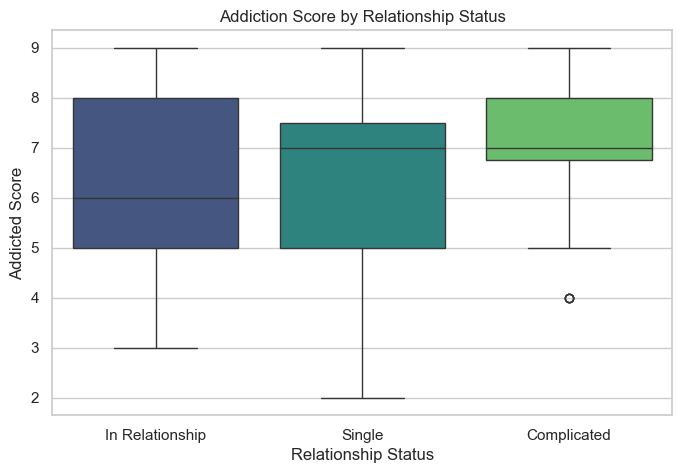

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Relationship_Status",
    y="Addicted_Score",
    palette="viridis"
)

plt.title("Addiction Score by Relationship Status")
plt.xlabel("Relationship Status")
plt.ylabel("Addicted Score")

plt.show()

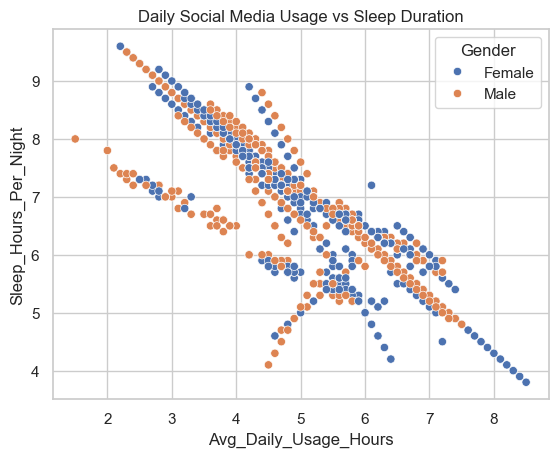

In [34]:
# Visualize the relationship between daily social media usage and sleep duration by gender
sns.scatterplot(
    data=df,
    x="Avg_Daily_Usage_Hours",
    y="Sleep_Hours_Per_Night",
    hue="Gender"
)

plt.title("Daily Social Media Usage vs Sleep Duration")
plt.show()

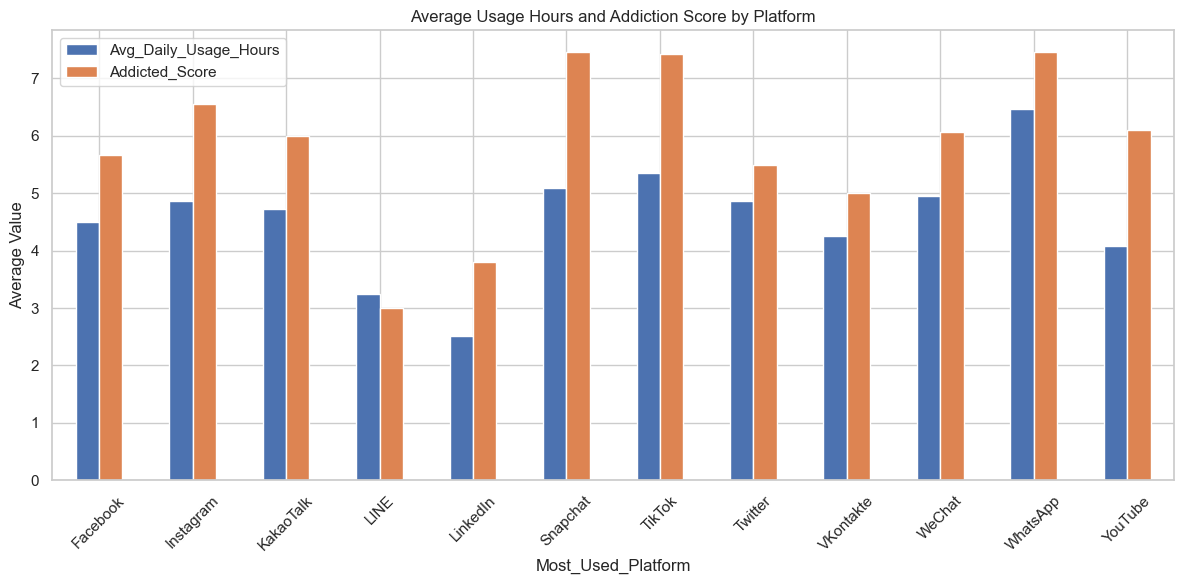

In [35]:
platform_analysis = df.groupby("Most_Used_Platform")[
    ["Avg_Daily_Usage_Hours", "Addicted_Score"]
].mean()
platform_analysis.plot(kind="bar",figsize=(12,6))

plt.title("Average Usage Hours and Addiction Score by Platform")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

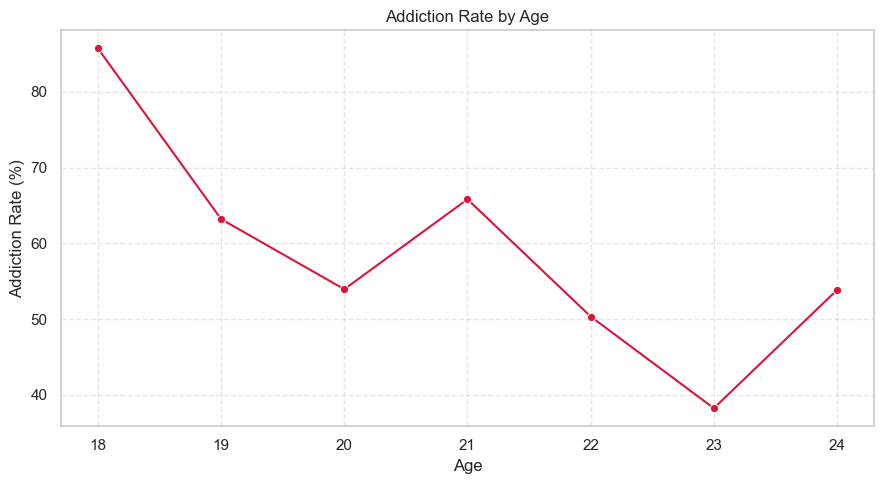

In [36]:

age_addiction = df.groupby('Age').agg(
    Addiction_Rate=('Addicted_Score', lambda s: (s >= 7).mean() * 100),
    Avg_Addiction_Score=('Addicted_Score', 'mean')
).reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=age_addiction, x='Age', y='Addiction_Rate', marker='o', color='crimson')
plt.title('Addiction Rate by Age')
plt.xlabel('Age')
plt.ylabel('Addiction Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


this shows that the age affect the target and that the younger are more likely to be addected

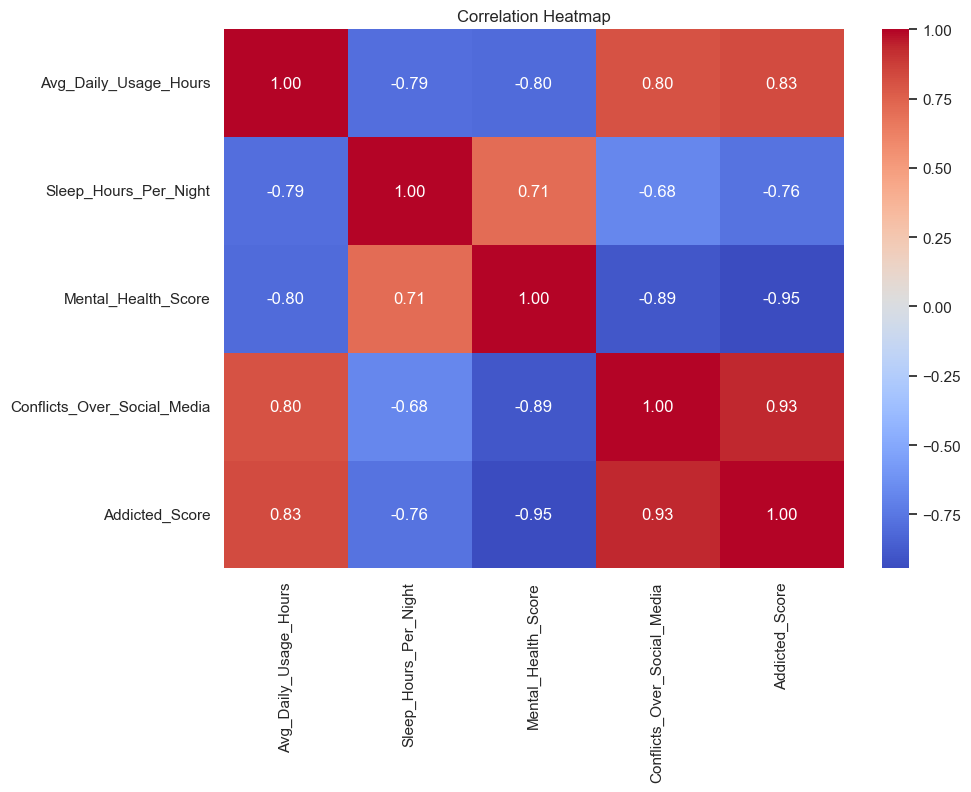

In [37]:
numerical_cols = [
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media',
    'Addicted_Score'
]
numeric_data = df[numerical_cols]
correlation = numeric_data.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")

plt.show()

this show that there is a high corelation between the features and this affect badly on the model performance

# feature enginering  & feature selection

In [38]:
# we can combine 'Avg_Daily_Usage_Hours','Sleep_Hours_Per_Night' into 'Usage_Sleep_Ratio'
df['Usage_Sleep_Ratio'] = ( df['Avg_Daily_Usage_Hours'] / df['Sleep_Hours_Per_Night'])
df = df.drop('Avg_Daily_Usage_Hours', axis=1)
df = df.drop('Sleep_Hours_Per_Night', axis=1)
df

,Age,Gender,Academic_Level,Country,Most_Used_Platform,Affects_Academic_Performance,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Usage_Sleep_Ratio
0,19,Female,Undergraduate,Bangladesh,Instagram,Yes,6,In Relationship,3,8,0.800000
1,22,Male,Graduate,India,Twitter,No,8,Single,0,3,0.280000
2,20,Female,Undergraduate,USA,TikTok,Yes,5,Complicated,4,9,1.200000
3,18,Male,High School,UK,YouTube,No,7,Single,1,4,0.428571
4,21,Male,Graduate,Canada,Facebook,Yes,6,In Relationship,2,7,0.750000
...,...,...,...,...,...,...,...,...,...,...,...
699,20,Female,Undergraduate,Italy,TikTok,No,7,In Relationship,2,5,0.652778
700,23,Male,Graduate,Russia,Instagram,Yes,4,Single,5,9,1.152542
701,21,Female,Undergraduate,China,WeChat,Yes,6,In Relationship,3,7,0.835821
702,24,Male,Graduate,Japan,Twitter,No,8,Single,2,4,0.573333


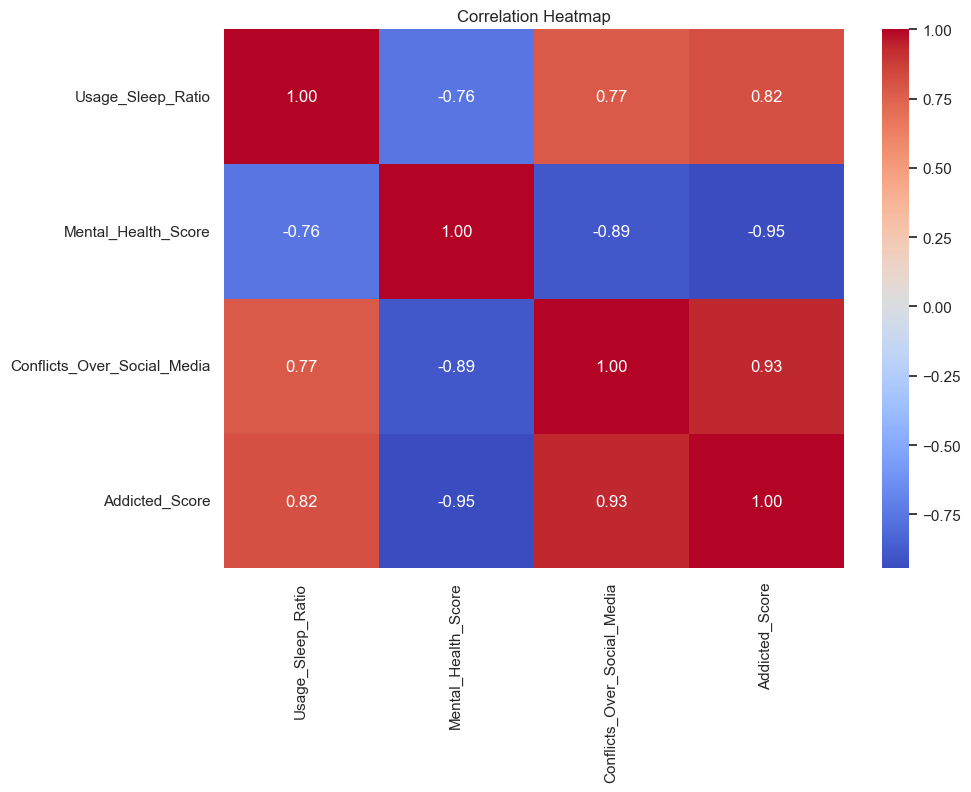

In [39]:
numerical_cols = [
    'Usage_Sleep_Ratio',
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media',
    'Addicted_Score'
]
numeric_data = df[numerical_cols]
correlation = numeric_data.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")

plt.show()

In [40]:
# 'Mental_Health_Score','Conflicts_Over_Social_Media' have a very high corelation with each other and actully they depend on each other so we will drop one of them
df = df.drop('Conflicts_Over_Social_Media', axis=1)

In [41]:
# the country feature showed that it didnt affect the targe
df = df.drop('Country', axis=1)

# spliting the data

In [42]:
# spliting the data
x=df[['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Mental_Health_Score',
       'Relationship_Status', 'Usage_Sleep_Ratio']]
y=df['Addicted_Score']
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)



In [43]:
# encoding
# ordinal encoding
ordinal_encoder = OrdinalEncoder(categories=[['High School', 'Undergraduate', 'Graduate']])
x_train['Academic_Level'] = ordinal_encoder.fit_transform(x_train[['Academic_Level']])
x_test['Academic_Level'] = ordinal_encoder.transform(x_test[['Academic_Level']])


In [44]:
categorical_cols = [
    'Gender',
    'Affects_Academic_Performance',
    'Relationship_Status',
    'Most_Used_Platform'
]

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Train
encoded_train = encoder.fit_transform(x_train[categorical_cols])

encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=x_train.index
)

# Test
encoded_test = encoder.transform(x_test[categorical_cols])

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=x_test.index
)
# Drop original categorical columns
x_train = x_train.drop(categorical_cols, axis=1)
x_test = x_test.drop(categorical_cols, axis=1)
# Add encoded columns
x_train = pd.concat([x_train, encoded_train_df], axis=1)
x_test = pd.concat([x_test, encoded_test_df], axis=1)

In [45]:
x_train

,Age,Academic_Level,Mental_Health_Score,Usage_Sleep_Ratio,Gender_Male,Affects_Academic_Performance_Yes,Relationship_Status_In Relationship,Relationship_Status_Single,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube
24,22,2.0,7,0.463768,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
155,20,1.0,5,0.567568,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
210,20,1.0,6,1.431818,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
291,19,1.0,4,1.283019,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
537,20,1.0,5,1.245614,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,21,2.0,7,0.470588,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,21,1.0,7,0.575758,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
270,20,1.0,7,0.616438,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
435,19,1.0,5,1.795455,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
# standarscaling to the numerical data
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()
numeric_cols=['Age' ,'Mental_Health_Score','Usage_Sleep_Ratio']
scaler = StandardScaler()
x_train_scaled[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test_scaled[numeric_cols] = scaler.transform( x_test[numeric_cols])

In [47]:
x_train_scaled

,Age,Academic_Level,Mental_Health_Score,Usage_Sleep_Ratio,Gender_Male,Affects_Academic_Performance_Yes,Relationship_Status_In Relationship,Relationship_Status_Single,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube
24,0.925591,2.0,0.683499,-0.922499,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
155,-0.500148,1.0,-1.148929,-0.599370,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
210,-0.500148,1.0,-0.232715,2.091055,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
291,-1.213018,1.0,-2.065143,1.627840,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
537,-0.500148,1.0,-1.148929,1.511399,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.212721,2.0,0.683499,-0.901268,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,0.212721,1.0,0.683499,-0.573874,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
270,-0.500148,1.0,0.683499,-0.447234,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
435,-1.213018,1.0,-1.148929,3.223060,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# models

we have x_train, x_test ,y_train,y_test,x_train_scaled,x_test_scaled

**Random Tree**


In [48]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dt_basic = DecisionTreeRegressor(random_state=42)
dt_basic.fit(x_train, y_train)

dt_scaled = DecisionTreeRegressor(random_state=42)
dt_scaled.fit(x_train_scaled, y_train)

dt_pruned = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)
dt_pruned.fit(x_train, y_train)

rf_default = RandomForestRegressor(n_estimators=100, random_state=42)
rf_default.fit(x_train, y_train)

models = {
    'DT (Unconstrained - Raw)': (dt_basic, x_test),
    'DT (Unconstrained - Scaled)': (dt_scaled, x_test_scaled),
    'DT (Pre-Pruned)': (dt_pruned, x_test),
    'RF (Default, n=100)': (rf_default, x_test),
}

for name, (model, x_eval) in models.items():
    preds = model.predict(x_eval)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"{name:30} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

DT (Unconstrained - Raw)       | MAE: 0.0851 | MSE: 0.0851 | RMSE: 0.2917 | R2: 0.9680
DT (Unconstrained - Scaled)    | MAE: 0.0851 | MSE: 0.0851 | RMSE: 0.2917 | R2: 0.9680
DT (Pre-Pruned)                | MAE: 0.1847 | MSE: 0.1133 | RMSE: 0.3366 | R2: 0.9574
RF (Default, n=100)            | MAE: 0.0889 | MSE: 0.0542 | RMSE: 0.2329 | R2: 0.9796


In [49]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)


xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)

print("--- XGBoost Performance ---")
print(f"R² Score: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.4f}")


--- XGBoost Performance ---
R² Score: 0.9798
MAE: 0.1115


In [50]:
def evaluate_model(name, model, x_eval):
    predictions = model.predict(x_eval)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_test, predictions),
        'MSE': mean_squared_error(y_test, predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test, predictions)),
        'R2': r2_score(y_test, predictions)
    }

comparison_table = pd.DataFrame([
    evaluate_model('Decision Tree (Raw)', dt_basic, x_test),
    evaluate_model('Decision Tree (Scaled)', dt_scaled, x_test_scaled),
    evaluate_model('Decision Tree (Pre-Pruned)', dt_pruned, x_test),
    evaluate_model('Random Forest', rf_default, x_test),
    evaluate_model('XGBoost', xgb_model, x_test)
])

comparison_table.sort_values('RMSE').reset_index(drop=True).round(4)

,Model,MAE,MSE,RMSE,R2
0,XGBoost,0.1115,0.0537,0.2318,0.9798
1,Random Forest,0.0889,0.0542,0.2329,0.9796
2,Decision Tree (Scaled),0.0851,0.0851,0.2917,0.9680
3,Decision Tree (Raw),0.0851,0.0851,0.2917,0.9680
4,Decision Tree (Pre-Pruned),0.1847,0.1133,0.3366,0.9574


**SVR**

In [51]:
from sklearn.svm import SVR
# Linear SVR - Raw
svr_linear_raw = SVR(kernel='linear', C=10, epsilon=0.1)
svr_linear_raw.fit(x_train, y_train)

y_pred_linear_raw = svr_linear_raw.predict(x_test)

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Linear SVR - Raw")
print("MAE:", mean_absolute_error(y_test, y_pred_linear_raw))
print("MSE:", mean_squared_error(y_test, y_pred_linear_raw))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear_raw)))
print("R2:", r2_score(y_test, y_pred_linear_raw))

Linear SVR - Raw
MAE: 0.1972226969119999
MSE: 0.10955549507903961
RMSE: 0.330991684304968
R2: 0.9588016796991302


In [53]:
# Linear SVR - Scaled
svr_linear_scaled = SVR(kernel='linear', C=10, epsilon=0.1)
svr_linear_scaled.fit(x_train_scaled, y_train)

y_pred_linear_scaled = svr_linear_scaled.predict(x_test_scaled)

In [54]:
print("Linear SVR - Scaled")
print("MAE:", mean_absolute_error(y_test, y_pred_linear_scaled))
print("MSE:", mean_squared_error(y_test, y_pred_linear_scaled))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear_scaled)))
print("R2:", r2_score(y_test, y_pred_linear_scaled))

Linear SVR - Scaled
MAE: 0.197364324585446
MSE: 0.10948201887618587
RMSE: 0.33088067165699764
R2: 0.9588293104093696


In [55]:
# RBF SVR - Raw
svr_rbf_raw = SVR(kernel='rbf', C=10, gamma=0.5, epsilon=0.1)
svr_rbf_raw.fit(x_train, y_train)

y_pred_rbf_raw = svr_rbf_raw.predict(x_test)

In [56]:
print("RBF SVR - Raw")
print("MAE:", mean_absolute_error(y_test, y_pred_rbf_raw))
print("MSE:", mean_squared_error(y_test, y_pred_rbf_raw))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rbf_raw)))
print("R2:", r2_score(y_test, y_pred_rbf_raw))

RBF SVR - Raw
MAE: 0.1589321874600966
MSE: 0.11395872524241948
RMSE: 0.3375777321483446
R2: 0.9571458459456658


In [57]:
# RBF SVR - Scaled
svr_rbf_scaled = SVR(kernel='rbf', C=10, gamma=0.5, epsilon=0.1)
svr_rbf_scaled.fit(x_train_scaled, y_train)

y_pred_rbf_scaled = svr_rbf_scaled.predict(x_test_scaled)

In [58]:
print("RBF SVR - Scaled")
print("MAE:", mean_absolute_error(y_test, y_pred_rbf_scaled))
print("MSE:", mean_squared_error(y_test, y_pred_rbf_scaled))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rbf_scaled)))
print("R2:", r2_score(y_test, y_pred_rbf_scaled))

RBF SVR - Scaled
MAE: 0.14869025413795947
MSE: 0.08951349558475546
RMSE: 0.29918806056518277
R2: 0.9663384692872716


 The scaled data performed better than the raw data especially with the RBF kernel.
 the RBF SVR with scaled data was selected as the best SVR model.bold **text**

**KNN**

In [59]:
#KNN on raw data
from sklearn.neighbors import KNeighborsRegressor

knn_raw = KNeighborsRegressor(n_neighbors=5)

knn_raw.fit(x_train_scaled, y_train)

y_pred_knn_raw = knn_raw.predict(x_test_scaled)

In [60]:
print("KNN - Raw")
print("MAE:", mean_absolute_error(y_test, y_pred_knn_raw))
print("MSE:", mean_squared_error(y_test, y_pred_knn_raw))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn_raw)))
print("R2:", r2_score(y_test, y_pred_knn_raw))

KNN - Raw
MAE: 0.124822695035461
MSE: 0.06695035460992908
RMSE: 0.2587476659023789
R2: 0.9748233335855337


In [61]:
def get_model_scores(name, model, x_eval):
    predictions = model.predict(x_eval)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_test, predictions),
        'MSE': mean_squared_error(y_test, predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test, predictions)),
        'R2': r2_score(y_test, predictions)
    }

all_models_comparison = pd.DataFrame([
    get_model_scores('Decision Tree (Raw)', dt_basic, x_test),
    get_model_scores('Decision Tree (Scaled)', dt_scaled, x_test_scaled),
    get_model_scores('Decision Tree (Pre-Pruned)', dt_pruned, x_test),
    get_model_scores('Random Forest', rf_default, x_test),
    get_model_scores('Linear SVR (Raw)', svr_linear_raw, x_test),
    get_model_scores('Linear SVR (Scaled)', svr_linear_scaled, x_test_scaled),
    get_model_scores('RBF SVR (Raw)', svr_rbf_raw, x_test),
    get_model_scores('RBF SVR (Scaled)', svr_rbf_scaled, x_test_scaled),
    get_model_scores('KNN', knn_raw, x_test)
])

all_models_comparison.sort_values('RMSE').reset_index(drop=True).round(4)

,Model,MAE,MSE,RMSE,R2
0,Random Forest,0.0889,0.0542,0.2329,0.9796
1,Decision Tree (Raw),0.0851,0.0851,0.2917,0.9680
2,Decision Tree (Scaled),0.0851,0.0851,0.2917,0.9680
3,RBF SVR (Scaled),0.1487,0.0895,0.2992,0.9663
4,Linear SVR (Scaled),0.1974,0.1095,0.3309,0.9588
5,Linear SVR (Raw),0.1972,0.1096,0.3310,0.9588
6,Decision Tree (Pre-Pruned),0.1847,0.1133,0.3366,0.9574
7,RBF SVR (Raw),0.1589,0.1140,0.3376,0.9571
8,KNN,2.8426,10.3166,3.2119,-2.8796


saving the model with higher scores

In [62]:
import joblib

joblib.dump(rf_default, 'mental_health_rf_model.pkl')


['mental_health_rf_model.pkl']